In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [81]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [82]:
df = pd.read_csv('/content/drive/MyDrive/Celebal Technologies/week2Dataset.csv')
display(df.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


Basic Information about the dataset

In [83]:
df.shape

(2640, 12)

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [85]:
# the dataset has no missing values, so no need to handle them
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


Performing EDA

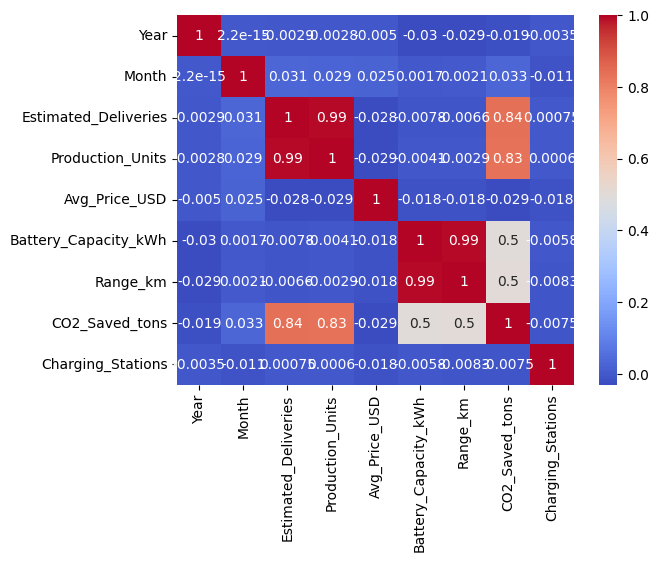

In [86]:
#heatmap of the correlation of the dataset
correlation= df.corr(numeric_only=True)
sns.heatmap(correlation, annot= True, cmap= 'coolwarm')
plt.show()

In [87]:
#estimated delivery and production units are highly related to each other.
#estimated deliveries and production units are also related to CO2 saved tons according to theheat map

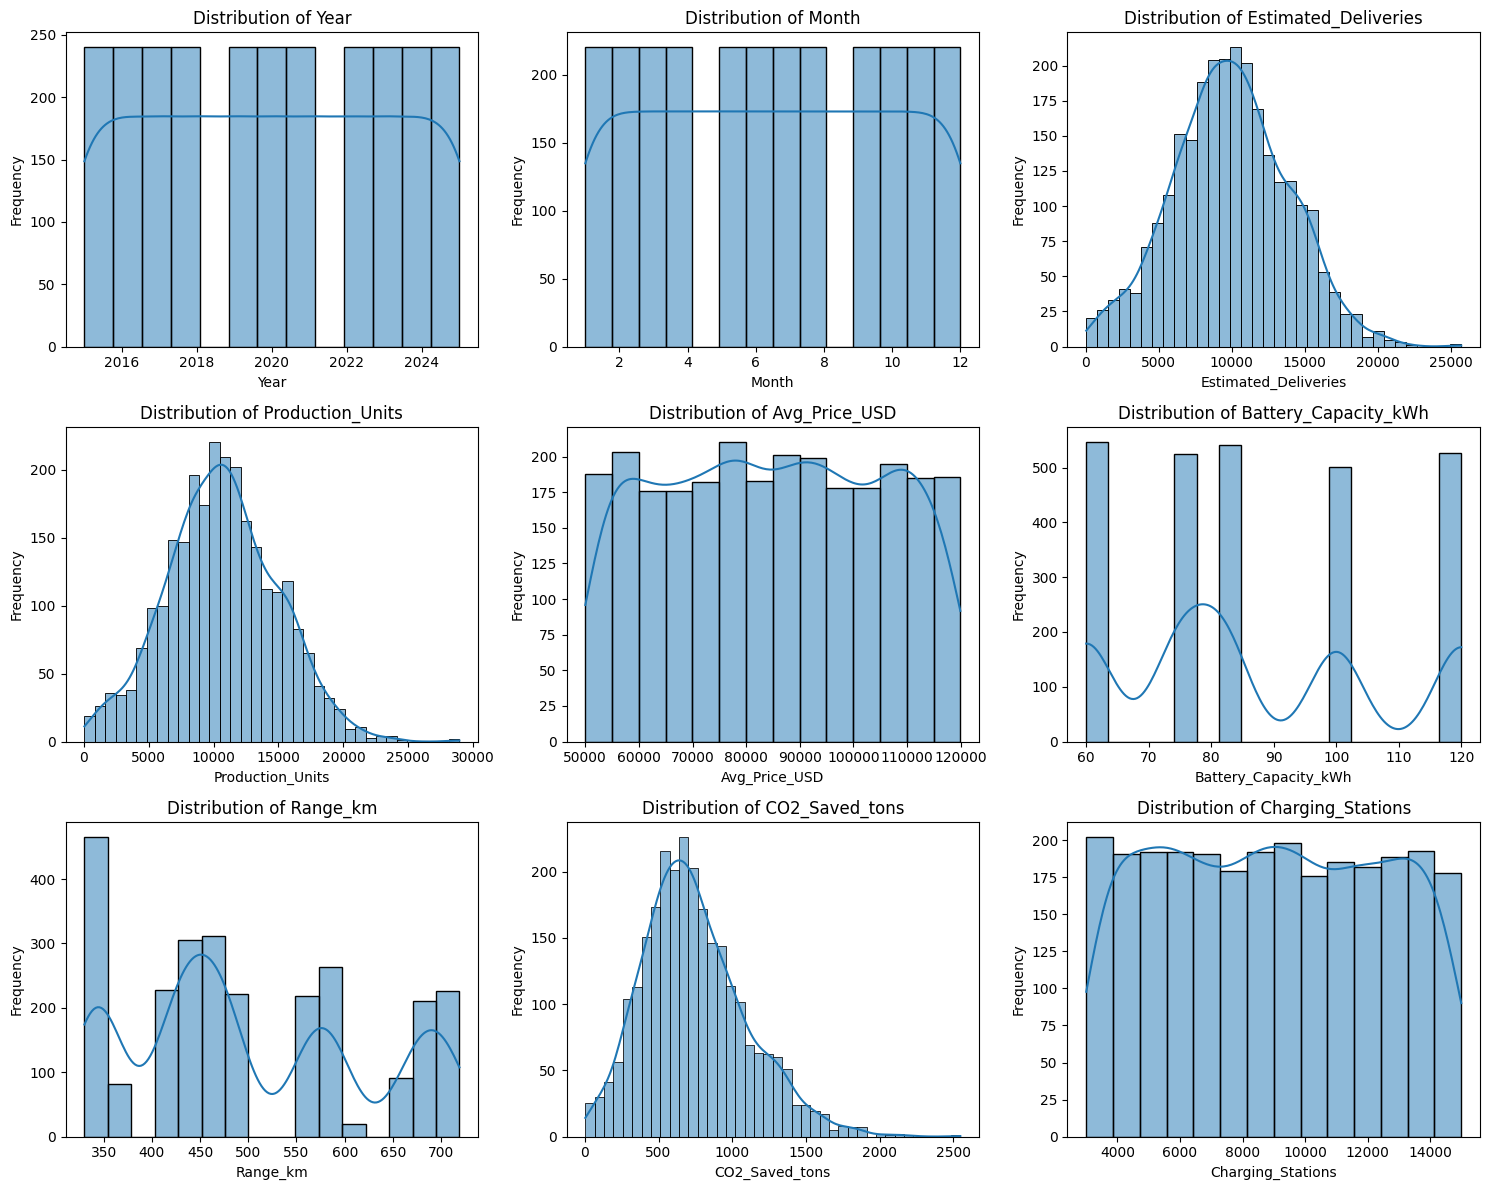

In [88]:
# plotting histogram for numerical features
numerical_features = ['Year', 'Month', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']

plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

/tmp/ipykernel_7807/1062358003.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_7807/1062358003.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_7807/1062358003.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


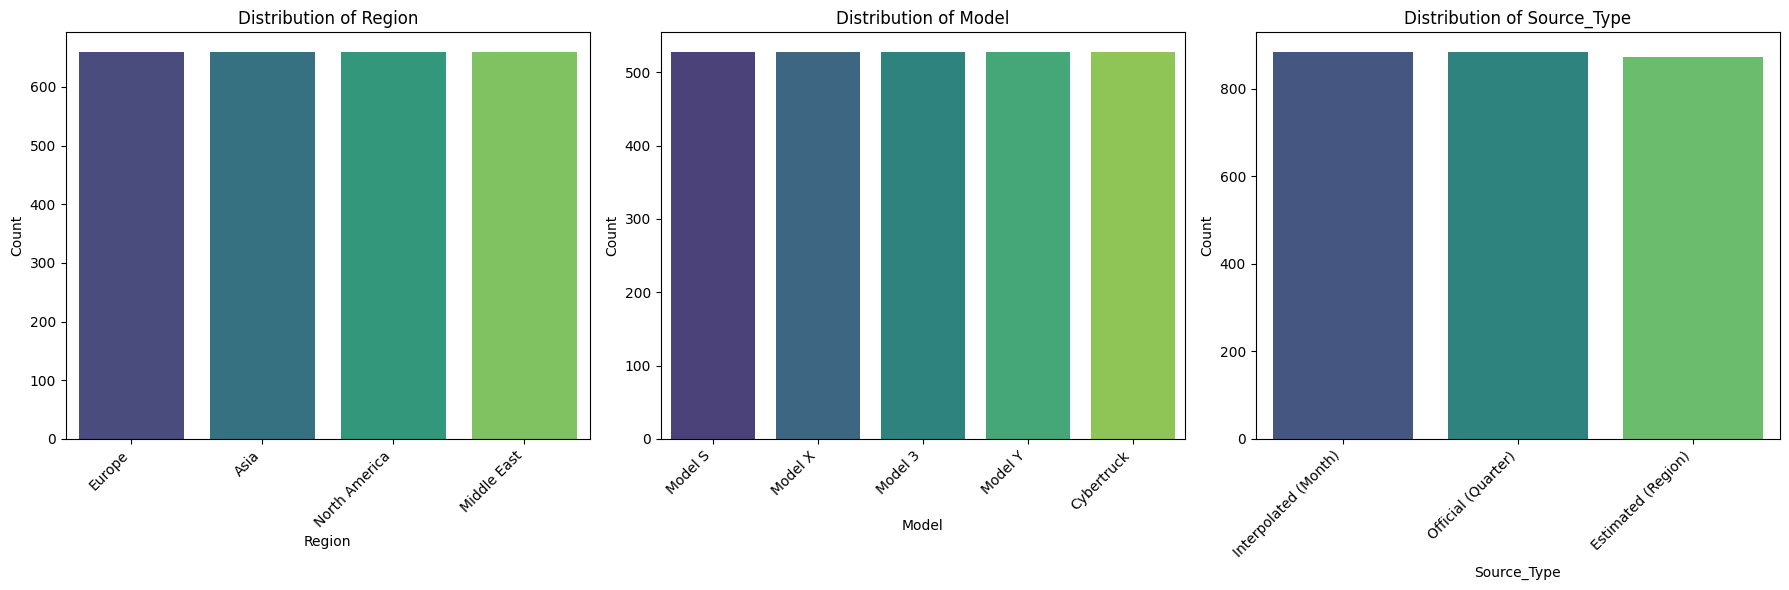

In [89]:
# analysing the categorical features
categorical_features = ['Region', 'Model', 'Source_Type']

plt.figure(figsize=(18, 6))
for i, col in enumerate(categorical_features):
    plt.subplot(1, 3, i + 1)
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Feature Engineering and Data Preprocessing

In [90]:
# Apply one-hot encoding to 'Region' and 'Model'
df = pd.get_dummies(df, columns=['Region', 'Model'], drop_first=True)

display(df.head())

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y
0,2023,5,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,True,False,False,False,True,False,False
1,2015,2,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,False,False,False,False,False,True,False
2,2019,1,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,False,False,True,False,False,True,False
3,2021,2,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,False,False,True,True,False,False,False
4,2016,12,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,False,True,False,False,False,False,True


/tmp/ipykernel_7807/426647685.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations_with_target.index, y=correlations_with_target.values, palette='coolwarm')


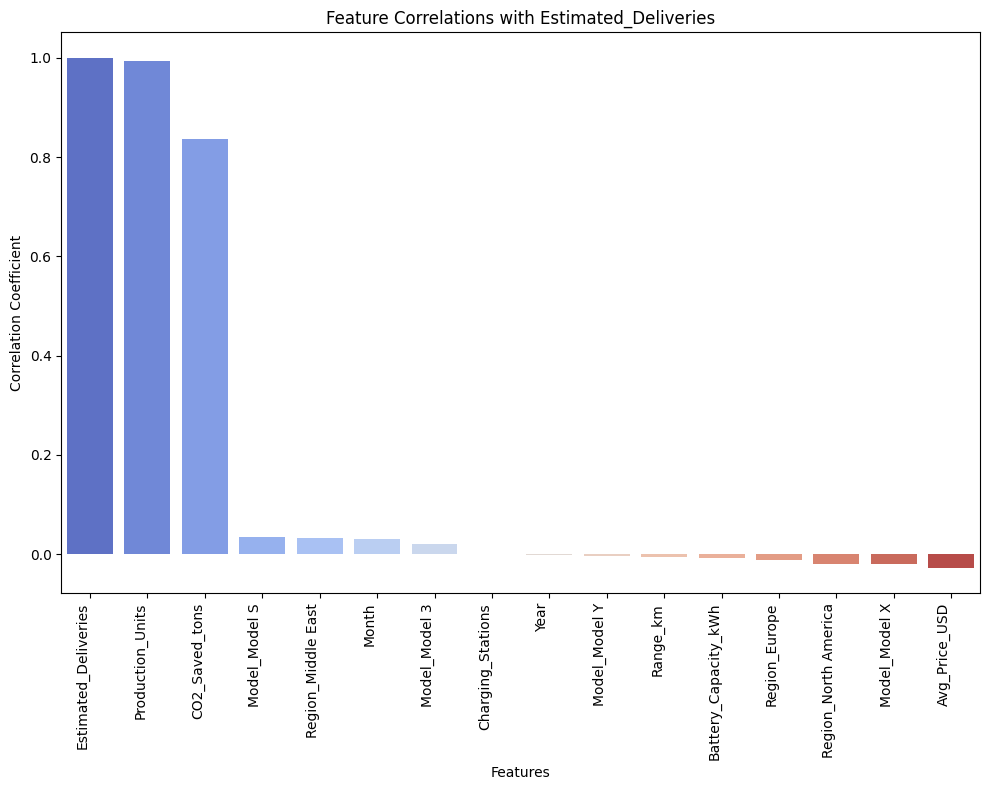

In [91]:
target_variable = 'Estimated_Deliveries'

# Calculate correlations with the target variable
correlations_with_target = df.corr(numeric_only=True)[target_variable].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=correlations_with_target.index, y=correlations_with_target.values, palette='coolwarm')
plt.title(f'Feature Correlations with {target_variable}')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

Scaling Numerical Features


In [92]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop(columns=[target_variable, 'Source_Type'])
y = df[target_variable]

# Identify numerical columns
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

display(X.head())

,Year,Month,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y
0,0.948683,-0.434524,1.705752,0.395982,1.581223,1.685972,3.169558,0.944062,True,False,False,False,True,False,False
1,-1.581139,-1.303572,-1.523982,-1.128346,-0.578883,-0.515183,-1.400569,-0.372490,False,False,False,False,False,True,False
2,-0.316228,-1.593255,-0.344347,1.639209,-0.242866,-0.167632,-0.392143,1.481407,False,False,True,False,False,True,False
3,0.316228,-1.303572,-0.785213,0.218076,1.581223,1.752172,-0.124611,0.115560,False,False,True,True,False,False,False
4,-1.264911,1.593255,0.676360,1.488085,1.581223,1.330146,1.367116,-0.060576,False,True,False,False,False,False,True


### Handling 'Source_Type' Categorical Feature

In [93]:
df_processed = pd.read_csv('/content/drive/MyDrive/Celebal Technologies/week2Dataset.csv')
# Apply one-hot encoding to 'Region' and 'Model' as done previously
df_processed = pd.get_dummies(df_processed, columns=['Region', 'Model'], drop_first=True)

# applying one-hot encoding to 'Source_Type'
df_processed = pd.get_dummies(df_processed, columns=['Source_Type'], drop_first=True)

# Separate features
X_updated = df_processed.drop(columns=[target_variable])
y_updated = df_processed[target_variable]

# Identify numerical columns for scaling
# Ensure we only select columns that are numeric and not already processed one-hot encoded columns (which are 0/1 already)
original_numerical_features = ['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
scaling_cols_updated = [col for col in original_numerical_features if col in X_updated.columns]

# Initialize and apply StandardScaler
scaler_updated = StandardScaler()
X_updated[scaling_cols_updated] = scaler_updated.fit_transform(X_updated[scaling_cols_updated])

print("Shape of X_updated after encoding Source_Type and scaling:", X_updated.shape)
display(X_updated.head())

Shape of X_updated after encoding Source_Type and scaling: (2640, 17)


,Year,Month,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,0.948683,-0.434524,1.705752,0.395982,1.581223,1.685972,3.169558,0.944062,True,False,False,False,True,False,False,True,False
1,-1.581139,-1.303572,-1.523982,-1.128346,-0.578883,-0.515183,-1.400569,-0.372490,False,False,False,False,False,True,False,False,True
2,-0.316228,-1.593255,-0.344347,1.639209,-0.242866,-0.167632,-0.392143,1.481407,False,False,True,False,False,True,False,True,False
3,0.316228,-1.303572,-0.785213,0.218076,1.581223,1.752172,-0.124611,0.115560,False,False,True,True,False,False,False,False,True
4,-1.264911,1.593255,0.676360,1.488085,1.581223,1.330146,1.367116,-0.060576,False,True,False,False,False,False,True,False,False


### Splitting Data with Encoded 'Source_Type'

In [94]:
# Split the updated data into training and testing sets
X_train_updated, X_test_updated, y_train_updated, y_test_updated = train_test_split(X_updated, y_updated, test_size=0.2, random_state=42)

print(f"X_train_updated shape: {X_train_updated.shape}")
print(f"X_test_updated shape: {X_test_updated.shape}")
print(f"y_train_updated shape: {y_train_updated.shape}")
print(f"y_test_updated shape: {y_test_updated.shape}")

X_train_updated shape: (2112, 17)
X_test_updated shape: (528, 17)
y_train_updated shape: (2112,)
y_test_updated shape: (528,)


### training Linear Regression

In [95]:
linear_reg_model_updated = LinearRegression()
linear_reg_model_updated.fit(X_train_updated, y_train_updated)

y_pred_linear_reg_updated = linear_reg_model_updated.predict(X_test_updated)

mae_linear_reg_updated = mean_absolute_error(y_test_updated, y_pred_linear_reg_updated)
mse_linear_reg_updated = mean_squared_error(y_test_updated, y_pred_linear_reg_updated)
rmse_linear_reg_updated = np.sqrt(mse_linear_reg_updated)
r2_linear_reg_updated = r2_score(y_test_updated, y_pred_linear_reg_updated)

print("--- Linear Regression Model Performance (with Source_Type) ---")
print(f"Mean Absolute Error (MAE): {mae_linear_reg_updated:.2f}")
print(f"Mean Squared Error (MSE): {mse_linear_reg_updated:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_linear_reg_updated:.2f}")
print(f"R-squared (R2): {r2_linear_reg_updated:.2f}")

--- Linear Regression Model Performance (with Source_Type) ---
Mean Absolute Error (MAE): 309.70
Mean Squared Error (MSE): 147478.36
Root Mean Squared Error (RMSE): 384.03
R-squared (R2): 0.99


### training Ridge Regression

In [96]:
ridge_reg_model_updated = Ridge(random_state=42)
ridge_reg_model_updated.fit(X_train_updated, y_train_updated)

y_pred_ridge_reg_updated = ridge_reg_model_updated.predict(X_test_updated)

mae_ridge_reg_updated = mean_absolute_error(y_test_updated, y_pred_ridge_reg_updated)
mse_ridge_reg_updated = mean_squared_error(y_test_updated, y_pred_ridge_reg_updated)
rmse_ridge_reg_updated = np.sqrt(mse_ridge_reg_updated)
r2_ridge_reg_updated = r2_score(y_test_updated, y_pred_ridge_reg_updated)

print("--- Ridge Regression Model Performance (with Source_Type) ---")
print(f"Mean Absolute Error (MAE): {mae_ridge_reg_updated:.2f}")
print(f"Mean Squared Error (MSE): {mse_ridge_reg_updated:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ridge_reg_updated:.2f}")
print(f"R-squared (R2): {r2_ridge_reg_updated:.2f}")

--- Ridge Regression Model Performance (with Source_Type) ---
Mean Absolute Error (MAE): 309.53
Mean Squared Error (MSE): 147504.21
Root Mean Squared Error (RMSE): 384.06
R-squared (R2): 0.99


### Re-training Lasso Regression with Updated Data

In [97]:
lasso_reg_model_updated = Lasso(random_state=42)
lasso_reg_model_updated.fit(X_train_updated, y_train_updated)

y_pred_lasso_reg_updated = lasso_reg_model_updated.predict(X_test_updated)

mae_lasso_reg_updated = mean_absolute_error(y_test_updated, y_pred_lasso_reg_updated)
mse_lasso_reg_updated = mean_squared_error(y_test_updated, y_pred_lasso_reg_updated)
rmse_lasso_reg_updated = np.sqrt(mse_lasso_reg_updated)
r2_lasso_reg_updated = r2_score(y_test_updated, y_pred_lasso_reg_updated)

print("--- Lasso Regression Model Performance (with Source_Type) ---")
print(f"Mean Absolute Error (MAE): {mae_lasso_reg_updated:.2f}")
print(f"Mean Squared Error (MSE): {mse_lasso_reg_updated:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lasso_reg_updated:.2f}")
print(f"R-squared (R2): {r2_lasso_reg_updated:.2f}")

--- Lasso Regression Model Performance (with Source_Type) ---
Mean Absolute Error (MAE): 309.49
Mean Squared Error (MSE): 146821.04
Root Mean Squared Error (RMSE): 383.17
R-squared (R2): 0.99


### Hyperparameter Tuning for Lasso Regression

In [98]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Lasso Regression
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Initialize Lasso model
lasso_model_ht = Lasso(random_state=42)

# Initialize GridSearchCV
grid_search_lasso = GridSearchCV(estimator=lasso_model_ht, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the updated training data
grid_search_lasso.fit(X_train_updated, y_train_updated)

print("Best parameters for Lasso Regression:", grid_search_lasso.best_params_)
print("Best RMSE for Lasso Regression:", np.sqrt(-grid_search_lasso.best_score_))

# Get the best Lasso model
best_lasso_model = grid_search_lasso.best_estimator_

# Make predictions with the best Lasso model
y_pred_best_lasso = best_lasso_model.predict(X_test_updated)

# Evaluate the best Lasso model
mae_best_lasso = mean_absolute_error(y_test_updated, y_pred_best_lasso)
mse_best_lasso = mean_squared_error(y_test_updated, y_pred_best_lasso)
rmse_best_lasso = np.sqrt(mse_best_lasso)
r2_best_lasso = r2_score(y_test_updated, y_pred_best_lasso)

print("\n--- Best Lasso Regression Model Performance (after Hyperparameter Tuning) ---")
print(f"Mean Absolute Error (MAE): {mae_best_lasso:.2f}")
print(f"Mean Squared Error (MSE): {mse_best_lasso:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_best_lasso:.2f}")
print(f"R-squared (R2): {r2_best_lasso:.2f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best parameters for Lasso Regression: {'alpha': 10}
Best RMSE for Lasso Regression: 389.2750495392306

--- Best Lasso Regression Model Performance (after Hyperparameter Tuning) ---
Mean Absolute Error (MAE): 310.07
Mean Squared Error (MSE): 146278.39
Root Mean Squared Error (RMSE): 382.46
R-squared (R2): 0.99


### Comparison of Model Performance

In [99]:
comparison_data = {
    'Model': ['Linear Regression (with Source_Type)', 'Ridge Regression (with Source_Type)', 'Lasso Regression (with Source_Type)', 'Lasso Regression (Tuned)'],
    'MAE': [mae_linear_reg_updated, mae_ridge_reg_updated, mae_lasso_reg_updated, mae_best_lasso],
    'MSE': [mse_linear_reg_updated, mse_ridge_reg_updated, mse_lasso_reg_updated, mse_best_lasso],
    'RMSE': [rmse_linear_reg_updated, rmse_ridge_reg_updated, rmse_lasso_reg_updated, rmse_best_lasso],
    'R2': [r2_linear_reg_updated, r2_ridge_reg_updated, r2_lasso_reg_updated, r2_best_lasso]
}

performance_df = pd.DataFrame(comparison_data)
display(performance_df.round(2))

,Model,MAE,MSE,RMSE,R2
0,Linear Regression (with Source_Type),309.70,147478.36,384.03,0.99
1,Ridge Regression (with Source_Type),309.53,147504.21,384.06,0.99
2,Lasso Regression (with Source_Type),309.49,146821.04,383.17,0.99
3,Lasso Regression (Tuned),310.07,146278.39,382.46,0.99


The comparison shows that while the R-squared values remain consistently high across all models, indicating they all explain a large proportion of the variance in estimated deliveries, the differences in MAE, MSE, and RMSE are very subtle. The hyperparameter-tuned Lasso Regression model achieves a slightly better (lower) RMSE and MSE compared to the initial Lasso model and the other baseline models. However, the improvement is not substantial, suggesting that the initial models were already performing quite well with the given feature set.